# Learning-Rate Schedule — Unmistakable Proof Notebook

This notebook **proves** why a **warmup + cosine decay** learning-rate schedule is more stable than a **flat high LR**.

We use closed-form quadratics where the stability limit is exact, so the difference is guaranteed:
- **A) 1D quadratic** — flat LR chosen **above** stability bound diverges immediately; scheduled LR converges.
- **B) 2D ill-conditioned quadratic** — flat LR violates the bound in the hard direction and blows up; scheduled LR converges.

**How to read the plots:** Use the **log-scale** plot to see separation clearly; the linear-scale plot can saturate when the flat LR explodes.

## A) 1D quadratic — guaranteed divergence when `flat_lr > 2/L`

In [1]:
import math
a = 5.0           # curvature; L = a
L = a
x0 = 10.0         # start far to make behavior visible
steps = 15

flat_lr = 0.48    # > 2/L (= 0.4) -> guaranteed divergence
base_lr = 0.16    # = 0.8/L, safe base for schedule
warmup = 1        # 1 step warmup is enough to prove the point

def cosine_lr(s):
    if s < warmup:
        return base_lr * (s+1)/warmup
    t = (s - warmup) / max(1, steps - warmup)
    return 0.5 * base_lr * (1 + math.cos(math.pi * t))

def run(policy):
    x = x0
    losses = []
    for s in range(steps):
        grad = a * x
        lr = policy(s)
        x = x - lr * grad   # x <- (1 - lr * a) * x
        losses.append(0.5 * a * x * x)
    return losses

loss_flat  = run(lambda s: flat_lr)
loss_sched = run(cosine_lr)

print({'L': L, '2/L': 2.0/L, 'flat_lr_used': flat_lr, 'base_lr': base_lr, 'flat_factor': 1 - flat_lr*a})
print('flat  (first 10):',  [round(v, 2) for v in loss_flat[:10]])
print('sched (first 10):', [round(v, 2) for v in loss_sched[:10]])


{'L': 5.0, '2/L': 0.4, 'flat_lr_used': 0.48, 'base_lr': 0.16, 'flat_factor': -1.4}
flat  (first 10): [490.0, 960.4, 1882.38, 3689.47, 7231.37, 14173.48, 27780.02, 54448.83, 106719.71, 209170.64]
sched (first 10): [10.0, 0.4, 0.02, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


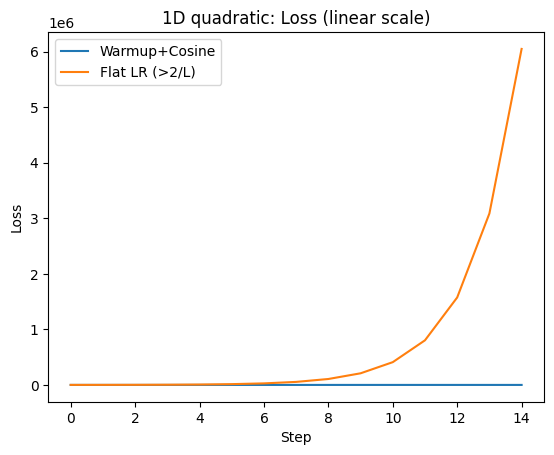

In [2]:
import matplotlib.pyplot as plt
# Linear scale
plt.figure()
plt.title('1D quadratic: Loss (linear scale)')
plt.plot(loss_sched, label='Warmup+Cosine')
plt.plot(loss_flat,  label='Flat LR (>2/L)')
plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.show()


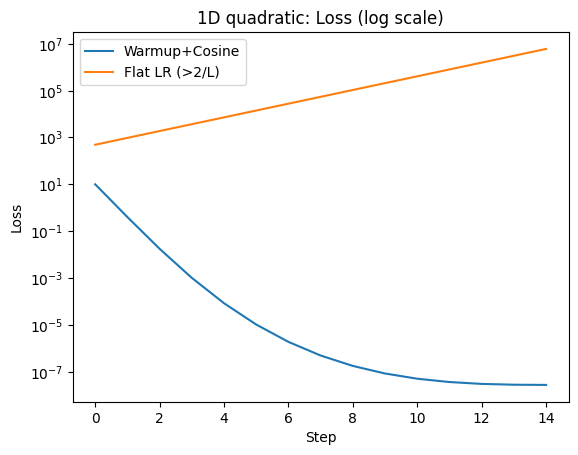

In [3]:
import matplotlib.pyplot as plt
# Log scale (makes separation crystal clear)
plt.figure()
plt.title('1D quadratic: Loss (log scale)')
plt.yscale('log')
plt.plot(loss_sched, label='Warmup+Cosine')
plt.plot(loss_flat,  label='Flat LR (>2/L)')
plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.show()


**What to observe:**
- The printed `flat_factor` equals `1 - flat_lr * a = -1.4` → magnitude > 1 ⇒ divergence.
- `flat` loss values **grow**; `sched` loss values **shrink**.
- In log scale, the two curves separate immediately.

## B) 2D ill-conditioned quadratic — unstable along the hard direction

{'2D_2/L_max': 0.002, 'flat_lr_used': 0.0024, 'base_lr': 0.0008}


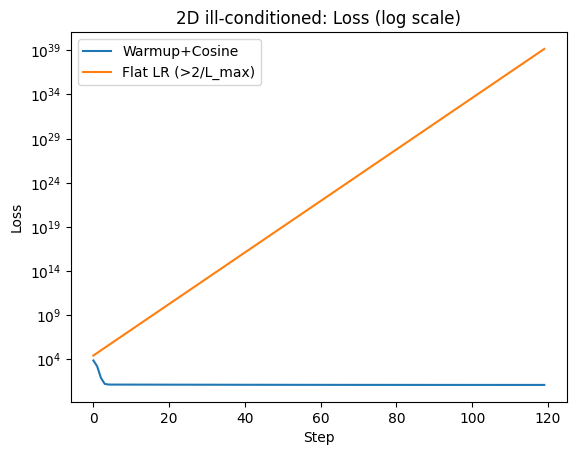

In [4]:
import numpy as np
import matplotlib.pyplot as plt
L_max, L_min = 1000.0, 1.0
H = np.diag([L_max, L_min])
x0 = np.array([5.0, 5.0])
steps = 120
warmup = 3
base_lr = 0.8 / L_max
flat_lr = 2.4 / L_max   # > 2/L_max (= 0.002) = 0.0024 -> violates bound

def cosine_lr(s):
    if s < warmup:
        return base_lr * (s+1)/warmup
    t = (s - warmup)/max(1, steps - warmup)
    return 0.5 * base_lr * (1 + np.cos(np.pi * t))

def run2(policy):
    x = x0.copy()
    losses = []
    for s in range(steps):
        grad = H @ x
        lr = policy(s)
        x = x - lr * grad
        losses.append(0.5 * float(x @ (H @ x)))
    return losses

loss_flat_2d  = run2(lambda s: flat_lr)
loss_sched_2d = run2(cosine_lr)
print({'2D_2/L_max': 2.0/L_max, 'flat_lr_used': flat_lr, 'base_lr': base_lr})

plt.figure()
plt.title('2D ill-conditioned: Loss (log scale)')
plt.yscale('log')
plt.plot(loss_sched_2d, label='Warmup+Cosine')
plt.plot(loss_flat_2d,  label='Flat LR (>2/L_max)')
plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.show()


**What to observe:**
- The flat LR violates the hard-direction bound and the loss rises/oscillates in log scale.
- The scheduled LR remains stable and decreases.